In [1]:
import pandas as pd
import numpy as np
import os
import math
from pathlib import Path
from matplotlib import pyplot as plt
idx = pd.IndexSlice
import xarray as xr
from read_mym import read_mym_df

from constants_BUMA import(
    SCENARIO_SELECT, FILE_ADDITION,
    REGIONS, REGIONS_RANGE,
    START_YEAR, END_YEAR, HIST_YEAR, YEARS, YEAR_LIST_SVA,
    INFLATION, 
    FLAG_ALPHA, FLAG_EXPDEC,
    LOWCOMM,
    GOMPERTZ_EXPDEC,
    MINIMUM_COM
)


In [2]:
base_directory = Path("..", "IMAGE-Mat_old_version", "IMAGE-Mat", "BUMA")
database_directory = base_directory / "files_DB" / SCENARIO_SELECT
image_directory = base_directory / "files_IMAGE" / SCENARIO_SELECT
assert database_directory.is_dir(), database_directory
assert image_directory.is_dir()


In [3]:
#%% # Reading all csv files for buildings that are external to IMAGE

# 1) scenario independent data
# Avg_m2_cap; unit: m2/capita; meaning: average square meters per person (by region & rural/urban) 
avg_m2_cap: pd.DataFrame = pd.read_csv(base_directory.joinpath('files_DB','Average_m2_per_cap.csv')) 

# 1) scenario dependent data 
# Housing_type; unit: %; meaning: the share of the PEOPLE living in a particular building type (by region & by area) 
housing_type: pd.DataFrame = pd.read_csv(database_directory.joinpath('Housing_type_dynamic.csv'), index_col = [0,1,2]) 
# Building_materials; unit: kg/m2; meaning: the average material use per square meter (by building type, by region & by area)
building_materials: pd.DataFrame = pd.read_csv(database_directory.joinpath('Building_materials' + FILE_ADDITION + '.csv'), index_col = [0,1,2]) 
# 7 building materials in 4 commercial building types; unit: kg/m2; meaning: the average material use per square meter (by commercial building type)
materials_commercial: pd.DataFrame = pd.read_csv(database_directory.joinpath('materials_commercial' + FILE_ADDITION + '.csv'), index_col = [0,1])  

# load IMAGE data-files (MyM file format)
floorspace: pd.DataFrame = read_mym_df(image_directory.joinpath("res_Floorspace.out"))
floorspace = floorspace[['time','DIM_1',2,3]].rename(columns={"DIM_1": "Region", 'time':'t', 2:'Urban', 3:'Rural'})
# the other columns are average per capita floorspace per quintile (we also exclude the average per capita floorspace of the total population in column 1, 
# because we use the urban & rural specific totals)
floorspace = floorspace[floorspace.Region != REGIONS + 1] #removing region 27
floorspace = floorspace[floorspace['t'].isin(list(range(START_YEAR, END_YEAR+1)))]
# remove all data beyond 2060 to save runtime, we have not yet generated scenario results beyond 2060

# Pop; unit: million of people; meaning: global population (over time, by region)             
population: pd.DataFrame = pd.read_csv(image_directory.joinpath('pop.csv'), index_col = [0]) 
# rurpop; unit: %; meaning: the share of people living in rural areas (over time, by region)
rural_population: pd.DataFrame = pd.read_csv(image_directory. joinpath('rurpop.csv'), index_col = [0])
# load historic population development
historic_population = pd.read_csv(base_directory / 'files_initial_stock' /'hist_pop.csv', index_col = [0])  
# initial population as a percentage of the 1970 population; unit: %; according to the Maddison Project Database (MPD) 2018 (Groningen University)

# we use the inflation corrected SVA to adjust for the fact that IMAGE provides gdp/cap in 2005 US$
service_value_added_2005: pd.DataFrame = pd.read_csv(image_directory.joinpath('sva_pc.csv'), index_col = [0])
service_value_added = service_value_added_2005 * INFLATION
# added cubic interpolation to the sva_pc (presumed linear interpolation between 5-year original data caused sawtooth demand/inflow throughout the scenario projection after 2025)
service_value_added = service_value_added.loc[YEAR_LIST_SVA,:].reindex(list(range(1970, END_YEAR + 1,1))).interpolate(method='cubic') 

# Load fitted regression parameters
if FLAG_ALPHA == 0:
    gompertz = pd.read_csv(base_directory / 'files_commercial/Gompertz_parameters.csv', index_col = [0])
else:
    gompertz = pd.read_csv(base_directory / 'files_commercial/Gompertz_parameters_alpha.csv', index_col = [0])


In [4]:
# Interpolate population and rural population data (fills in missing years with cubic interpolation)
rural_population = rural_population.reindex(YEARS).interpolate(method='cubic')
population = population.reindex(YEARS).interpolate(method='cubic')
# Remove 1st year, to ensure same Table size as floorspace data (from 1971)
#population = population.iloc[1:]
#rural_population = rural_population.iloc[1:]

#pre-calculate urban population
urban_population = 1 - rural_population    
# urban population is 1 - the fraction of people living in rural areas (rural_population)

# also interpolate housing type data
index_ht = pd.MultiIndex.from_product([list(range(HIST_YEAR, END_YEAR + 1)), 
                                       list(range(1,REGIONS + 1)), 
                                       ['Urban', 'Rural'] ]) 
housing_type = pd.DataFrame(np.nan, index=index_ht, columns=housing_type.columns)

for year in list(housing_type.index.levels[0]):
    housing_type.loc[idx[year,:,:],:] = housing_type.loc[idx[year,:,:],:]
    
for region in list(range(1,REGIONS + 1)):
    for area in ['Urban', 'Rural']:
        housing_types_interpolated = housing_type.loc[idx[:,region,area],:].interpolate(method='linear', limit_direction='both')
        housing_type.loc[idx[:,region,area],:] = housing_types_interpolated.values                                                     
       

In [5]:
# Select gompertz curve paramaters for the total commercial m2 demand (stock)
alpha, beta, gamma = (
    (gompertz['All']['a'], gompertz['All']['b'], gompertz['All']['c'])
    if FLAG_EXPDEC == 0 else GOMPERTZ_EXPDEC          
)
alpha_low = alpha * LOWCOMM                                    # alpha multiplied with a factor, lowering the maximum per capita commecrial floorspace between (2020 and 2050) 

# find the total commercial m2 stock (in Millions of m2)
commercial_m2_cap = pd.DataFrame(index=YEARS, columns=REGIONS_RANGE)
commercial_m2_cap_low = commercial_m2_cap.copy()

# Compute commercial floorspace using Gompertz curves
for year in YEARS:
    for region in REGIONS_RANGE:
        exp_factor = math.exp((-gamma/1000) * service_value_added[str(region)][year])
        if FLAG_EXPDEC == 0:
            commercial_m2_cap[region][year] = alpha * math.exp(-beta * exp_factor)
            commercial_m2_cap_low[region][year] = alpha_low * math.exp(-beta * exp_factor)
        else:
            commercial_m2_cap[region][year] = max(0.542, alpha - beta * exp_factor)

# commercial floorspace is scaled here (in case lowComm is not 1)
scale_comm = pd.Series([1.0, 0.0], index=[2020, 2060], name='time').reindex(YEARS).interpolate(method='linear', limit=300, limit_direction='both')
commercial_m2_cap    = commercial_m2_cap.mul(scale_comm, axis=0) + commercial_m2_cap_low.mul((1-scale_comm), axis=0)


C:\Users\5982758\AppData\Local\Temp\ipykernel_5264\2903140353.py:17: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  commercial_m2_cap[region][year] = alpha * math.exp(-beta * exp_factor)
C:\Users\5982758\AppData\Local\Temp\ipykernel_5264\2903

In [6]:
# Subdivide the total commercial floorspace across Offices, Retail+, Govt+ & Hotels+
types = ["Office", "Retail+", "Hotels+", "Govt+"]
index = pd.MultiIndex.from_product([types, REGIONS_RANGE, YEARS], names=["Type", "Region", "Year"])
commercial_m2_cap_all = pd.DataFrame(index=index, columns=["m2_per_cap"]).fillna(0)

#TODO move to a util file
# Define a function to calculate Gompertz growth
def gompertz_value(category, region, year, sva_data):
    """Calculate the Gompertz value for a given category, region, and year."""
    params = gompertz[category]
    return params['a'] * math.exp(-params['b'] * math.exp((-params['c'] / 1000) * sva_data[str(region)][year]))

for year in YEARS:
    for region in REGIONS_RANGE:
        # Calculate floorspace for all types and update the minimum values
        floorspace_commercial_list = {}
        for type_ in types:
            #value = gompertz_value(type_, region, year, service_value_added)
            params = gompertz[type_]
            value = params['a'] * math.exp(-params['b'] * math.exp((-params['c'] / 1000) * service_value_added[str(region)][year]))
            floorspace_commercial_list[type_] = value
            MINIMUM_COM[type_] = min(MINIMUM_COM[type_], value)

        # Sum all floorspace values for normalization
        commercial_sum = sum(floorspace_commercial_list.values())

        # Calculate and assign the floorspace for each type
        for type_ in types:
            commercial_m2_cap_all.loc[(type_, region, year), "m2_per_cap"] = (
                commercial_m2_cap.loc[year, region] * (floorspace_commercial_list[type_] / commercial_sum)
            )


C:\Users\5982758\AppData\Local\Temp\ipykernel_5264\3519961243.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  commercial_m2_cap_all = pd.DataFrame(index=index, columns=["m2_per_cap"]).fillna(0)
C:\Users\5982758\AppData\Local\Temp\ipykernel_5264\3519961243.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  commercial_m2_cap_all.loc[(type_, region, year), "m2_per_cap"] = (
C:\Users\5982758\AppData\Local\Temp\ipykernel_5264\3519961243.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.86773961804217' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  commercial_m2_cap_all.loc[(type_, region, year), "m2_per_cap"] = (


In [7]:
# Reshaping and merging commercial and residential floorspace
floorspace = floorspace.rename({"t":"Year"}, axis = 1)
floorspace = floorspace.set_index(["Year", "Region"])
floorspace = floorspace.rename_axis("Type", axis = 1)
commercial_m2_cap_all = commercial_m2_cap_all.unstack("Type")
commercial_m2_cap_all = commercial_m2_cap_all.droplevel(0, axis = 1)
floorspace = floorspace.merge(commercial_m2_cap_all, how = "left", left_index=True, right_index=True)
floorspace_dataset = floorspace.to_xarray()

In [26]:
# Deriving historic population tail based on fraction for 1970
population_1970 = population.loc[1970]
historic_population = historic_population.multiply(population_1970, axis=1)
population = pd.concat([historic_population, population])

In [27]:
population

,1,2,3,4,5,6,7,8,9,10,...,17,18,19,20,21,22,23,24,25,26
1820,0.804857,10.202035,6.494014,3.995169,4.490184,6.560494,11.351722,18.828342,15.384226,1.556748,...,15.345110,213.859540,13.833770,386.793973,19.409805,17.930819,31.172610,0.481581,34.878730,9.664120
1821,0.839675,10.527078,6.529342,4.069134,4.580745,6.702825,11.465243,18.974172,15.671461,1.576775,...,15.415683,214.721118,13.842147,389.536410,19.586585,18.079851,31.205794,0.478252,35.160736,9.811451
1822,0.874493,10.861319,6.564669,4.143100,4.671306,6.845155,11.578765,19.120002,15.958696,1.596802,...,15.486256,215.586788,13.850524,392.296995,19.763366,18.229883,31.238978,0.476033,35.442743,9.958782
1823,0.909311,11.193516,6.599997,4.217065,4.761867,6.988519,11.692286,19.265831,16.245931,1.616828,...,15.556829,216.455529,13.858901,395.078753,19.940146,18.380915,31.272161,0.476033,35.724749,10.106113
1824,0.944129,11.526736,6.635324,4.291031,4.852428,7.131883,11.805807,19.411661,16.533167,1.636855,...,15.627402,217.327339,13.867277,397.878660,20.116927,18.533948,31.305345,0.479362,36.006756,10.253444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2056,49.466338,409.713990,157.282240,109.659693,233.636573,263.010809,250.080438,996.330605,603.512415,67.122345,...,397.680805,1768.533559,68.641286,1269.986906,459.182415,305.710721,106.460710,47.751794,653.676547,330.938179
2057,49.751604,411.565524,157.371071,109.684560,233.236354,263.245528,250.599935,1007.299438,609.412950,67.215053,...,400.008158,1772.409068,68.119521,1259.387485,459.207281,305.124793,105.832242,48.069896,656.423017,334.203382
2058,50.034694,413.421703,157.426121,109.688451,232.799590,263.435411,251.066444,1018.101089,615.200189,67.301219,...,402.239939,1775.760598,67.593553,1248.655412,459.158818,304.472594,105.201908,48.382597,659.012994,337.412746
2059,50.315641,415.282729,157.447121,109.671414,232.329723,263.581516,251.479915,1028.746847,620.872112,67.381260,...,404.375326,1778.570219,67.064597,1237.806359,459.037951,303.753303,104.569223,48.689735,661.447460,340.567607


In [10]:
population.loc[[1970]]
#historic_population 

,1,2,3,4,5,6,7,8,9,10,...,17,18,19,20,21,22,23,24,25,26
t,,,,,,,,,,,,,,,,,,,,,
1970,21.453,209.593,52.03,43.247,95.327,97.516,72.867,140.449,83.817,22.839,...,66.833,553.579,46.619,844.879,165.772,117.363,104.926,17.186,159.163,46.499


In [11]:
floorspace_array = xr.DataArray(0.0, dims=("Year", "Region", "type"), coords={
    "Year": floorspace_dataset.coords["Year"],
    "Region": floorspace_dataset.coords["Region"],
    "type": ["Urban", "Rural", "Office", "Retail+", "Hotels+", "Govt+"],
})

In [12]:
for data_name, data_var in floorspace_dataset.data_vars.items():
    floorspace_array.loc[:, :, data_name] = data_var

In [13]:
# For the RESIDENTIAL & COMMERCIAL floorspace: Derive the annual trend (in m2/cap) 
# over the initial 10 years of IMAGE data
# Get the growth by year (for the first 10 years)
interp_coor = floorspace_array.sel(Year=range(1971, 1981)).coords
trend_1971_1981 = xr.DataArray(
    floorspace_array.sel(Year=range(1971, 1981)).to_numpy()/floorspace_array.sel(Year=range(1972, 1982)).to_numpy(),
    dims=("Year", "Region", "type"),
    coords=interp_coor
)

In [14]:
# Average global annual decline in floorspace/cap in %, rural: 1%; urban 1.2%;  commercial: 1.26-2.18% /yr 
avg_trend_1971_1981 = trend_1971_1981.mean(["Year", "Region"])

In [15]:
# Find minumum or maximum values in the original IMAGE data 
# (Just for residential, commercial minimum values have been calculated above)
min_floorspace = floorspace_array.min(["Year", "Region"])

In [16]:
# define historic floorspace (1820-1970) in m2/cap
# Calculate the actual values used between 1820 & 1970, given the trends & the min/max values
start_year = 1820
end_year = 1971
delta_year = end_year - start_year
fraction_interpol = avg_trend_1971_1981.values.reshape(1, -1)**(delta_year - np.arange(end_year-start_year)).reshape(-1, 1)
reshaped_floor_1971 = floorspace_array.loc[1971, :, :].values.reshape(1, *floorspace_array.shape[1:])
interpol_floor_1820_1970_np = reshaped_floor_1971*fraction_interpol.reshape(fraction_interpol.shape[0], 1, -1)
where_too_low = np.where(interpol_floor_1820_1970_np < min_floorspace.values)
interpol_floor_1820_1970_np[where_too_low] = min_floorspace.values[where_too_low[-1]]
interpol_floor_1820_1970_xr = xr.DataArray(interpol_floor_1820_1970_np, dims=floorspace_array.dims,
                                           coords={
                                               "Year": np.arange(start_year, end_year),
                                               "Region": floorspace_array.coords["Region"],
                                               "type": floorspace_array.coords["type"]
                                           })

In [17]:
# To avoid full model setup in 1820 (all required stock gets built in yr 1) 
# we assume another tail that linearly increases to the 1820 value over a 100 year 
# time period, so 1720 = 0
far_start_year = 1721
interpol_floor_1721_1820 = np.linspace(0, interpol_floor_1820_1970_np[0, :, :], num=(start_year - far_start_year), endpoint=False)
interpol_floor_1721_1820_xr = xr.DataArray(interpol_floor_1721_1820,
                                           dims=floorspace_array.dims,
                                           coords={
                                               "Year": np.arange(far_start_year, start_year),
                                               "Region": floorspace_array.coords["Region"],
                                               "type": floorspace_array.coords["type"]
                                           })

In [18]:
# combine historic with IMAGE data here
floorspace_xr = xr.concat((interpol_floor_1721_1820_xr, interpol_floor_1820_1970_xr, floorspace_array), dim="Year")

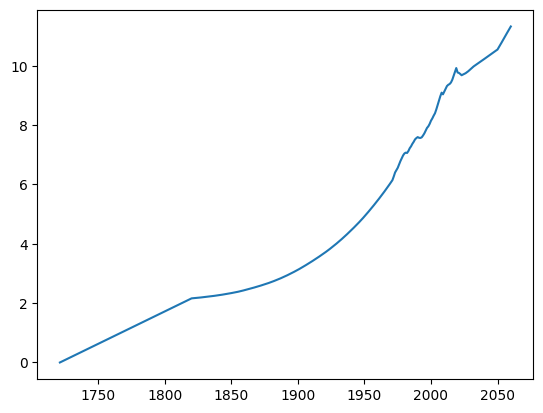

In [19]:
plt.plot(floorspace_xr.coords["Year"], floorspace_xr.mean(["Region", "type"]))
plt.show()